# Graphlet 

In [1]:
import numpy as np
import torch
import pandas as pd

In [2]:
# 读取包含药物名称和SMILES分子式的表格文件
df = pd.read_csv('data/Merk/ONEIL_DRUG.csv')

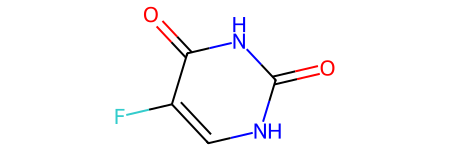

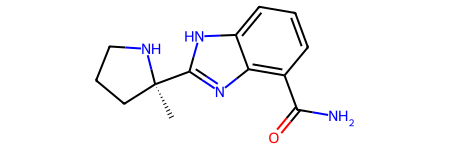

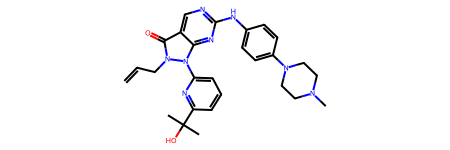

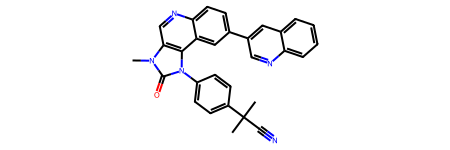

In [3]:
from rdkit.Chem import MolFromSmiles,AddHs
df['mol'] = df['SMILES'].map(MolFromSmiles)
from IPython.display import display
n_molecules_to_display = 4
for m in df['mol'][:n_molecules_to_display]:
    display(m)

In [4]:
?FingerprintFeaturizer

Object `FingerprintFeaturizer` not found.


In [5]:
?GraphletFingerprinter

Object `GraphletFingerprinter` not found.


In [6]:
from minervachem.transformers import FingerprintFeaturizer
import minervachem.fingerprinters as fps

fingerprinter = FingerprintFeaturizer(
    fps.GraphletFingerprinter(
        max_len=6, 
        useHs=True # Note: in this notebook, we use the `useHs` argument to have explicit hydrogens.
    ),
    return_dense=True,
    n_jobs=-3, # If your computer experiences memory problems, you can set the number of jobs lower.
    verbose=1,
    chunk_size='auto',
)

In [7]:
df_fea = fingerprinter.fit_transform(df['mol'])
df_fea

Finding fingerprints in fit


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 14 concurrent workers.


Constructing Fingerprints:   0%|          | 0/38 [00:00<?, ?it/s]

N bits: 4937
Converting bits to array form


[Parallel(n_jobs=-3)]: Done  38 out of  38 | elapsed:    3.3s finished


Converting FPs to sparse:   0%|          | 0/38 [00:00<?, ?it/s]

Converting from sparse to dense
Sparse Transform time: 0.00333 s/mol


array([[0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 6, 0],
       ...,
       [0, 0, 0, ..., 0, 8, 0],
       [0, 0, 0, ..., 0, 2, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [8]:
# 将特征转换为DataFrame
df_fea_df = pd.DataFrame(df_fea)

# 将特征DataFrame连接到原始DataFrame
df_combined = pd.concat([df, df_fea_df], axis=1)

# 保存到新的CSV文件
df_combined.to_csv('data/Merk/Graphlet_features_6.csv', index=True)

In [9]:
from minervachem.transformers import FingerprintFeaturizer
import minervachem.fingerprinters as fps
import pandas as pd

# 初始化指纹特征提取器
fingerprinter = FingerprintFeaturizer(
    fps.GraphletFingerprinter(
        max_len=6, 
        useHs=True  # 使用显式氢原子
    ),
    return_dense=True,
    n_jobs=-3,  # 如果内存不足，可以减少作业数量
    verbose=1,
    chunk_size='auto',
)

# 拟合并转换分子数据
df_fea = fingerprinter.fit_transform(df['mol'])

# 获取 bit IDs 作为列名
bit_ids = fingerprinter.bit_ids_
column_names = [f"bit_{bit_id}" for bit_id in bit_ids]

# 将特征转换为DataFrame，并使用 bit IDs 作为列名
df_fea_df = pd.DataFrame(df_fea, columns=column_names)

# 将特征DataFrame连接到原始DataFrame
df_combined = pd.concat([df, df_fea_df], axis=1)

# 保存包含特征的数据到CSV文件
df_combined.to_csv('data/Merk/Graphlet_features_6.csv', index=True)

# 创建 bit ID 与分子式的对应关系文件
# 注意：这里需要根据实际的指纹生成器获取分子式信息
# 由于 GraphletFingerprinter 可能不直接提供分子式，我们可以保存 bit ID 和大小信息

# 创建 bit 信息 DataFrame
bit_info_df = pd.DataFrame({
    'bit_id': bit_ids,
    'bit_size': fingerprinter.bit_sizes_,
    'bit_index': range(len(bit_ids))  # 添加列索引位置
})

# 保存 bit 信息到文件
bit_info_df.to_csv('data/Merk/Graphlet_bit_info_6.csv', index=False)

print(f"特征维度: {df_fea.shape}")
print(f"Bit IDs 数量: {len(bit_ids)}")
print(f"特征文件已保存: data/Merk/Graphlet_features_6.csv")
print(f"Bit 信息文件已保存: data/Merk/Graphlet_bit_info_6.csv")

# 如果需要更详细的分子式信息，可以尝试获取指纹生成器的内部信息
try:
    # 尝试获取更详细的片段信息
    if hasattr(fingerprinter.fingerprinter, 'get_fragment_info'):
        fragment_info = []
        for bit_id in bit_ids:
            info = fingerprinter.fingerprinter.get_fragment_info(bit_id)
            fragment_info.append(info)
        
        # 如果有片段信息，添加到 bit_info_df
        bit_info_df['fragment_smiles'] = fragment_info
        bit_info_df.to_csv('data/Merk/Graphlet_bit_detailed_info_6.csv', index=False)
        print(f"详细 Bit 信息文件已保存: data/Merk/Graphlet_bit_detailed_info_6.csv")
        
except Exception as e:
    print(f"无法获取详细片段信息: {e}")
    print("只保存了基本的 bit ID 和大小信息")

Finding fingerprints in fit


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 14 concurrent workers.


Constructing Fingerprints:   0%|          | 0/38 [00:00<?, ?it/s]

N bits: 4937
Converting bits to array form


[Parallel(n_jobs=-3)]: Done  38 out of  38 | elapsed:    0.6s finished


Converting FPs to sparse:   0%|          | 0/38 [00:00<?, ?it/s]

Converting from sparse to dense
Sparse Transform time: 0.00362 s/mol
特征维度: (38, 4937)
Bit IDs 数量: 4937
特征文件已保存: data/Merk/Graphlet_features_6.csv
Bit 信息文件已保存: data/Merk/Graphlet_bit_info_6.csv


In [10]:
from minervachem.transformers import FingerprintFeaturizer
import minervachem.fingerprinters as fps
import pandas as pd
from rdkit import Chem

# 初始化指纹特征提取器
fingerprinter = FingerprintFeaturizer(
    fps.GraphletFingerprinter(
        max_len=6, 
        useHs=True
    ),
    return_dense=True,
    n_jobs=-3,
    verbose=1,
    chunk_size='auto',
)

# 拟合并转换分子数据
df_fea = fingerprinter.fit_transform(df['mol'])

# 获取 bit IDs
bit_ids = fingerprinter.bit_ids_
column_names = [f"bit_{bit_id}" for bit_id in bit_ids]

# 创建特征 DataFrame
df_fea_df = pd.DataFrame(df_fea, columns=column_names)
df_combined = pd.concat([df, df_fea_df], axis=1)
df_combined.to_csv('data/Merk/Graphlet_features_6.csv', index=True)

# 尝试从原始分子中提取片段信息
def extract_fragment_smiles(molecules, fingerprinter, bit_ids):
    """尝试从分子中提取对应片段的SMILES"""
    fragment_smiles = []
    
    for bit_id in bit_ids:
        found_smiles = None
        # 尝试在每个分子中查找这个bit_id对应的片段
        for mol in molecules:
            if mol is None:
                continue
            try:
                # 这里需要根据具体的指纹生成器API来获取片段信息
                # 这只是一个示例，实际方法可能不同
                info = fingerprinter.fingerprinter.get_fragment_info(mol, bit_id)
                if info and hasattr(info, 'smiles'):
                    found_smiles = info.smiles
                    break
            except:
                continue
        
        fragment_smiles.append(found_smiles if found_smiles else f"Unknown_{bit_id}")
    
    return fragment_smiles

# 创建 bit 信息表
bit_info_df = pd.DataFrame({
    'bit_id': bit_ids,
    'bit_size': fingerprinter.bit_sizes_,
    'column_name': column_names,
    'column_index': range(len(bit_ids))
})

# 如果可能的话，添加片段SMILES
try:
    # 这里假设指纹生成器有获取片段信息的方法
    # 实际使用时可能需要根据具体的API调整
    fragment_smiles = []
    for bit_id in bit_ids:
        # 尝试获取片段表示
        # 这需要根据 minervachem 的具体实现来调整
        fragment_smiles.append(f"Graphlet_{bit_id}")
    
    bit_info_df['fragment_representation'] = fragment_smiles
except Exception as e:
    print(f"无法获取片段详细信息: {e}")
    bit_info_df['fragment_representation'] = [f"Graphlet_{bit_id}" for bit_id in bit_ids]

# 保存 bit 信息
bit_info_df.to_csv('data/Merk/Graphlet_bit_info_6.csv', index=False)

print("处理完成!")
print(f"特征矩阵形状: {df_fea.shape}")
print(f"Bit IDs 数量: {len(bit_ids)}")
print(f"特征文件: data/Merk/Graphlet_features_6.csv")
print(f"Bit 信息文件: data/Merk/Graphlet_bit_info_6.csv")

Finding fingerprints in fit


[Parallel(n_jobs=-3)]: Using backend LokyBackend with 14 concurrent workers.


Constructing Fingerprints:   0%|          | 0/38 [00:00<?, ?it/s]

N bits: 4937
Converting bits to array form


[Parallel(n_jobs=-3)]: Done  38 out of  38 | elapsed:    0.6s finished


Converting FPs to sparse:   0%|          | 0/38 [00:00<?, ?it/s]

Converting from sparse to dense
Sparse Transform time: 0.00327 s/mol
处理完成!
特征矩阵形状: (38, 4937)
Bit IDs 数量: 4937
特征文件: data/Merk/Graphlet_features_6.csv
Bit 信息文件: data/Merk/Graphlet_bit_info_6.csv
